# Karan Bedi - Prodigal AI Assignment
## Task 4 - Domain Shift and Robustness


## Importing Libraries

These imports support robustness perturbations, local inference, LoRA fine-tuning, evaluation metrics, and visualisation. The task combines prompt robustness with fine-tuning, so both inference and training utilities are needed.


In [36]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Device count:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())

CUDA available: True
GPU name: NVIDIA GeForce RTX 4060 Ti
Device count: 1
Current device: 0


In [37]:
import json
import os
import re
import time
from datetime import datetime
#from edgegemma_8gb import llm_call
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from copy import deepcopy
from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
import google.generativeai as genai
import anthropic
from datasets import load_dataset
from datasets import load_dataset, load_from_disk
from peft import LoraConfig, get_peft_model


## Loading the Dataset

Yelp is used as the in-domain dataset because the earlier tasks already establish its five-class sentiment setup. This gives a consistent baseline before testing whether the model transfers to a different review domain.


In [38]:
dataset = load_dataset('yelp_review_full', split='test[:15]')
# While ive loaded the full dataset, ill be using a small sample
dataset = dataset.map(lambda x: {"stars": x["label"] + 1})# This is 0 indexed, we want stars from 1-5

## Loading the JSON Helpers

The JSON helpers make robustness evaluation possible by distinguishing malformed outputs from wrong predictions. This is important because perturbations can affect both sentiment reasoning and output formatting.


In [39]:
def clean_json(text):
    """Strip markdown fences and return the last valid {...} block."""
    if text is None:
        return None
    text = re.sub(r"```json\s*|```", "", text).strip()
    matches = re.findall(r'\{[^{}]+\}', text, re.DOTALL)
    return matches[-1] if matches else None


def safe_parse(text):
    """Parse JSON; return (dict, ok). Returns (None, False) on failure — never crashes."""
    if text is None:
        return None, False
    cleaned = clean_json(text)
    if not cleaned:
        return None, False
    try:
        parsed = json.loads(cleaned)
        if isinstance(parsed, dict):
            return parsed, True
        return None, False
    except (json.JSONDecodeError, ValueError):
        return None, False

## Setting Up Gemma

Gemma 2B is loaded locally so robustness and fine-tuning experiments can run without API limits. The quantized setup is a practical compromise between available hardware and the need to run many evaluation passes.


In [40]:
model_id = "google/gemma-2b-it"

# Check if model already exists in memory before loading incase you have to run all 
if 'model' not in globals() or 'tokenizer' not in globals():
    print(f"Loading {model_id} into memory...")
    
    # Since i only have 8gb vram i will run a 4-bit quantized model
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,   #fastest safe option without halucinations 
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"              # better accuracy than default
    )

    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    #Load model efficiently to address slow down
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        quantization_config=bnb_config,
        torch_dtype=torch.float16,             # ensures fast compute
        low_cpu_mem_usage=True                 # reduces overhead
    )

    #its a faster mode
    model.eval()
    print("Model loaded successfully on:", model.device)
    
else:
    print(f"Model already loaded in memory on: {model.device}. Skipping initialization.")

Model already loaded in memory on: cuda:0. Skipping initialization.


## LLM Call Function

This call uses the chat template, which is required for reliable instruction-following with Gemma-2b-it. Keeping the inference format consistent is important before attributing errors to robustness or domain shift.


In [41]:
def llm_call(prompt, system=None, max_new_tokens=150):
    """Call Gemma-2b-it using the chat template (required for instruction following)."""
    user_content = (system + "\n\n" + prompt) if system else prompt
    messages = [{"role": "user", "content": user_content}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to("cuda")
    input_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )
    new_tokens = outputs[0][input_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

## Robustness Prompts: v1 / v2 / v3

The prompt versions test whether clearer rating rules and robustness instructions improve stability under noisy inputs. This supports the decision about whether prompt engineering alone can reduce sensitivity to surface changes.


In [42]:
# v1 — baseline: same as original MULTI_TASK_PROMPT, no robustness instructions
ROBUST_V1 = """You are an AI assistant.
For the given review, do the following:
1. Predict star rating (1-5)
2. Classify sentiment (positive / neutral / negative)
3. Provide a short summary (1 sentence)
IMPORTANT: Output ONLY valid JSON. No extra text.
Format: {"stars": <1-5>, "sentiment": "positive|neutral|negative", "summary": "..."}
"""

# v2 — structured: explicit star-to-sentiment mapping, stricter format gate
ROBUST_V2 = """You are a strict JSON generator.
Classify the review using these anchors:
  1=very negative, 2=negative, 3=neutral/mixed, 4=positive, 5=very positive
  sentiment mapping: 1-2 → "negative",  3 → "neutral",  4-5 → "positive"
Output ONLY this JSON — no other text:
{"stars": <integer 1-5>, "sentiment": "positive|neutral|negative", "summary": "<one sentence>"}
"""

# v3 — robust: handle noise, casing variation, and negation explicitly
ROBUST_V3 = """You are a strict JSON generator.
Classify the review into 1-5 stars.
Robustness rules — apply before answering:
  - Ignore ALL-CAPS or all-lowercase — case does not change meaning
  - Ignore punctuation noise (!!!, ...) — focus on the words only
  - Negation phrases ("not good", "not great", "barely okay") → rate LOWER
  - Sarcasm after complaints → treat as negative
Star scale: 1=terrible, 2=poor, 3=average, 4=good, 5=excellent
Sentiment: 1-2="negative", 3="neutral", 4-5="positive"
Output ONLY this JSON on one line:
{"stars": <1-5>, "sentiment": "positive|neutral|negative", "summary": "<one sentence>"}
"""

# Keep the original name so multi_task_classify and the main robustness loop still work
MULTI_TASK_PROMPT = ROBUST_V1

# Iteration registry — drives run_task4_robustness_eval
ROBUSTNESS_ITERATIONS = [
    ("v1 — baseline",    ROBUST_V1),
    ("v2 — structured",  ROBUST_V2),
    ("v3 — robust",      ROBUST_V3),
]

## Multi-Task Classifier

The classifier applies the selected prompt to each review and extracts a structured star prediction. Keeping this function stable across prompt versions makes the robustness comparison fair.


In [43]:
def multi_task_classify(text):
    prompt = f"{MULTI_TASK_PROMPT}\n\nReview: {text[:250]}"
    raw = llm_call(prompt)
    cleaned = clean_json(raw)
    parsed, ok = safe_parse(cleaned)
    return parsed, ok

## Adding Noise and Changing the Data

The perturbations test different kinds of robustness: casing changes, punctuation noise, and meaning-preserving or polarity-shifting substitutions. This helps separate superficial formatting sensitivity from deeper sentiment understanding.


In [44]:
def to_lower(text):
    return text.lower()


def add_noise(text):
    return re.sub(r'\b(\w)\b', r'\1!!!', text)


def simple_negation(text):
    return text.replace("good", "not bad").replace("great", "not bad")

## Applying Said Changes

The same base reviews are transformed into perturbed variants. This decision was made so differences in accuracy are driven by the perturbation, not by comparing different review samples.


In [45]:
def apply_perturbations(text):
    return {
        "original": text,
        "lower": to_lower(text),
        "noise": add_noise(text),
        "negation": simple_negation(text)
    }

## Running the Model with These Changes

The model is evaluated on original and perturbed inputs using the same classifier. This allows the result to show whether the prediction changes when the review meaning should mostly remain stable.


In [46]:
robustness_results = []

for row in dataset:
    variants = apply_perturbations(row["text"])

    entry = {"true": row["stars"]}

    for k, v in variants.items():
        pred, ok = multi_task_classify(v)

        entry[k] = pred["stars"] if ok else None

    robustness_results.append(entry)

## Evaluate Robustness

The robustness evaluation compares accuracy across perturbation types. A stable model should show only small changes for harmless perturbations, while larger drops suggest sensitivity to surface form or tokenisation.


In [47]:
def eval_robustness(results, key):
    valid = [(r["true"], r[key]) for r in results if r[key] is not None]

    if len(valid) == 0:
        return 0

    return accuracy_score(
        [x[0] for x in valid],
        [x[1] for x in valid]
    )


for k in ["original", "lower", "noise", "negation"]:
    acc = eval_robustness(robustness_results, k)
    print(f"{k}: {acc:.3f}")

original: 0.333
lower: 0.333
noise: 0.333
negation: 0.333


## Visualisation

The visualisation makes it easier to compare perturbation effects across prompt versions. The goal is to identify which prompt decisions improve stability rather than only reading raw tables.


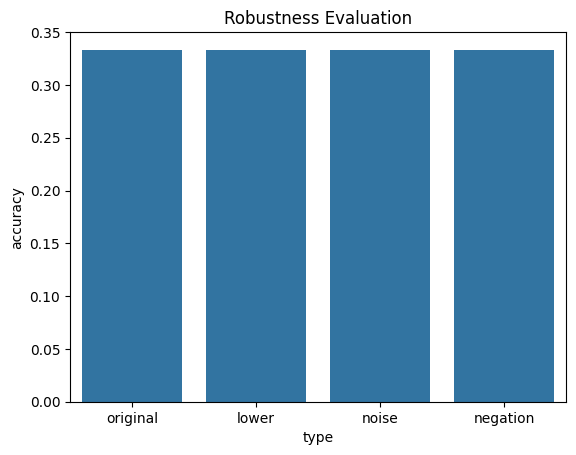

In [48]:
data = []

for k in ["original", "lower", "noise", "negation"]:
    data.append({
        "type": k,
        "accuracy": eval_robustness(robustness_results, k)
    })

df = pd.DataFrame(data)

sns.barplot(data=df, x="type", y="accuracy")
plt.title("Robustness Evaluation")
plt.show()

## Fine-Tuning Gemma

Fine-tuning tests whether LoRA adaptation improves in-domain Yelp performance and how that affects transfer to IMDB. This section moves beyond prompting and asks whether changing model weights improves robustness or creates domain overfitting.


### Note on LoRA and Mixed-Domain Results

Because the model runs locally, full fine-tuning is not practical here, so LoRA is used as a lightweight adaptation method.

The mixed-domain results should be interpreted cautiously. The later mixed-domain inference path used raw string concatenation instead of `apply_chat_template`, while the main Gemma call used the proper chat-template format. This pipeline mismatch likely contributed to the IMDB accuracy collapsing to near-random performance.

This indicates a pipeline issue, not a definitive failure of mixed-domain training. Before drawing a strong conclusion about whether Yelp plus IMDB training helps transfer, the mixed-domain evaluation should be rerun with the same chat-template inference path used elsewhere.


In [49]:
BASE_DIR = '/mnt/d/School NEw/ProdigalINterviewTest/data' # Change this for your environment
yelp_train_path = os.path.join(BASE_DIR, 'yelp_train_2k')
yelp_test_path = os.path.join(BASE_DIR, 'yelp_test_200')
imdb_test_path = os.path.join(BASE_DIR, 'imdb_test_200')
# Checking if the yelp dataset exists if not dowload
if os.path.exists(yelp_train_path) and os.path.exists(yelp_test_path):
    print("Loading Yelp subsets from local storage...")
    train_ds = load_from_disk(yelp_train_path)
    test_yelp = load_from_disk(yelp_test_path)
else:
    print("Local Yelp data not found. Downloading from Hugging Face...")
    yelp = load_dataset("yelp_review_full")
    train_ds = yelp["train"].select(range(2000))   # keep small
    test_yelp = yelp["test"].select(range(200))
    
    print("Saving Yelp subsets locally...")
    train_ds.save_to_disk(yelp_train_path)
    test_yelp.save_to_disk(yelp_test_path)
#Checking if the imdb datset exists, if not download and save
if os.path.exists(imdb_test_path):
    print("Loading IMDB subset from local storage...")
    test_imdb = load_from_disk(imdb_test_path)
else:
    print("Local IMDB data not found. Downloading from Hugging Face...")
    imdb = load_dataset("imdb")
    test_imdb = imdb["test"].select(range(200))
    
    print("Saving IMDB subset locally...")
    test_imdb.save_to_disk(imdb_test_path)

print("\nAll datasets are ready to go!")

Loading Yelp subsets from local storage...
Loading IMDB subset from local storage...

All datasets are ready to go!


## Formatting Data for Training

The training format converts labelled examples into text the model can learn from. This step matters because the format used during fine-tuning should match the format expected during evaluation as closely as possible.


In [50]:
def format_example(example):
    return {
        "text": f"Review: {example['text']}\nStars: {example['label'] + 1}"
    }

train_ds = train_ds.map(format_example, keep_in_memory=True)

Map: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 6646.00 examples/s]


## Adding LoRA

LoRA is used to adapt a small set of parameters instead of updating the full model. This decision was made to fit the hardware constraint while still testing whether task-specific training can improve sentiment classification.


In [51]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 921,600 || all params: 2,507,094,016 || trainable%: 0.036759690467068624


## Training Setup

The training settings balance speed, memory, and stability. Because the dataset and epoch count are small, the results should be read as a directional experiment rather than a fully optimised fine-tuning run.


In [52]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=2,
    max_steps=300,
    logging_steps=10,
    save_strategy="no"
)

## Trainer

The trainer connects the formatted dataset, LoRA adapter, and training arguments. This makes the fine-tuning procedure reproducible and separates training configuration from evaluation.


In [53]:
def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256   # important
    )

    tokens["labels"] = tokens["input_ids"].copy()  #required for training

    return tokens

train_tokenized = train_ds.map(tokenize, batched=True)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized
)

Map: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [00:01<00:00, 1862.40 examples/s]
max_steps is given, it will override any value given in num_train_epochs


## Training Gemma 2B

This run adapts Gemma on Yelp examples. The decision being tested is whether lightweight in-domain training improves Yelp classification and whether that improvement transfers or overfits.


In [54]:
torch.cuda.empty_cache()
trainer.train()

Step,Training Loss
10,13.152400
20,10.479700
30,8.789400
40,10.120300
50,8.735600
60,8.320800
70,7.356000
80,6.440900
90,7.550700
100,5.940200


TrainOutput(global_step=300, training_loss=6.231466382344564, metrics={'train_runtime': 93.1148, 'train_samples_per_second': 6.444, 'train_steps_per_second': 3.222, 'total_flos': 1827354024345600.0, 'train_loss': 6.231466382344564, 'epoch': 0.3})

## Evaluation Function

The evaluation function standardises prediction and metric calculation across Yelp and IMDB. This is necessary so any domain gap reflects model behaviour rather than different scoring logic.


In [55]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=20
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

## Evaluate on Yelp

Yelp evaluation measures in-domain performance after training. This indicates whether LoRA learned the target task on the same domain used for adaptation.


In [56]:
for row in test_yelp.select(range(5)):
    print(predict(row["text"]))

I got 'new' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the hole patched, but they said the reason I had a flat was because the previous patch had blown - WAIT, WHAT? I just got the tire and never needed to have it patched? This was supposed to be a new tire. \nI took the tire over to Flynn's and they told me that someone punctured my tire, then tried to patch it. So there are resentful tire slashers? I find that very unlikely. After arguing with the guy and telling him that his logic was far fetched he said he'd give me a new tire \"this time\". \nI will never go back to Flynn's b/c of the way this guy treated me and the simple fact that they gave me a used tire! I will never trust them again.
Don't waste your time.  We had two different people come to our house to give us estimates for a deck (one of them the OWNER).  Both times, we never heard from them.  Not a call, not the estimate, nothing.  We had to call the company b

## Evaluate on IMDB

IMDB evaluation measures out-of-domain transfer. Since IMDB is binary sentiment and Yelp is five-class ratings, the mapping is approximate, so the result should be interpreted as a transfer signal rather than a perfect like-for-like comparison.


In [57]:
for row in test_imdb.select(range(5)):
    print(predict(row["text"]))

I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome with a 'sci-fi' setting. (I'm sure there are those of you out there who think Babylon 5 is good sci-fi TV. It's not. It's clichéd and uninspiring.) While US viewers might like emotion and character development, sci-fi is a genre that does not take itself seriously (cf. Star Trek). It may treat important issues, yet not as a serious philosophy. It's really difficult to care about the characters here as they are not simply foolish, just missing a spark of life. Their actions and reactions are wooden and predictable, often painful to watch. The makers of Earth KNOW it's rubbish as they have to alway

## Metrics-Based Evaluation: Baseline vs Fine-Tuned

A consistent evaluation prompt is used before and after LoRA training on both Yelp and IMDB. This decision was made so the comparison reflects the adapter state rather than changes in prompting.


In [58]:
EVAL_SYSTEM = """You are a strict JSON generator.
Classify the review into 1-5 stars.
Output ONLY JSON: {"stars": <1-5>}"""


def extract_stars_robust(text):
    """Try JSON first, then fall back to the 'Stars: X' continuation format the fine-tuned model learned."""
    cleaned = clean_json(text)
    parsed, ok = safe_parse(cleaned)
    if ok and parsed and isinstance(parsed.get("stars"), int):
        s = parsed["stars"]
        if 1 <= s <= 5:
            return s
    m = re.search(r"[Ss]tars?\s*:?\s*(\d)", text or "")
    if m:
        s = int(m.group(1))
        if 1 <= s <= 5:
            return s
    return None


def eval_yelp(model_fn, dataset, sample_size=20):
    """5-class accuracy and macro-F1 on Yelp (labels are 0-indexed, convert to 1-5)."""
    preds, trues = [], []
    for row in dataset.select(range(min(sample_size, len(dataset)))):
        raw = model_fn(f"Review: {row['text'][:250]}", EVAL_SYSTEM)
        pred = extract_stars_robust(raw)
        if pred is not None:
            preds.append(pred)
            trues.append(row["label"] + 1)
    if not preds:
        return 0.0, 0.0
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro", labels=list(range(1, 6)), zero_division=0)
    return round(acc, 3), round(f1, 3)


def eval_imdb_binary(model_fn, dataset, sample_size=20):
    """Binary accuracy on IMDB: stars<=2 → neg(0), stars>=4 → pos(1), skip 3."""
    preds, trues = [], []
    for row in dataset.select(range(min(sample_size, len(dataset)))):
        raw = model_fn(f"Review: {row['text'][:250]}", EVAL_SYSTEM)
        pred = extract_stars_robust(raw)
        if pred is not None:
            if pred <= 2:
                preds.append(0)
            elif pred >= 4:
                preds.append(1)
            else:
                continue
            trues.append(row["label"])
    if not preds:
        return 0.0
    return round(accuracy_score(trues, preds), 3)


print("Eval functions ready.")

Eval functions ready.


### Step 1: Baseline (LoRA Disabled)

LoRA adapters are disabled to evaluate the unmodified Gemma 2B-IT model. This creates the reference point for measuring the effect of fine-tuning.


In [59]:
import torch
torch.cuda.empty_cache()
model.eval()

print("Running BASELINE evaluation (LoRA disabled)...")
model.disable_adapter_layers()

base_yelp_acc, base_yelp_f1 = eval_yelp(llm_call, test_yelp, sample_size=20)
base_imdb_acc = eval_imdb_binary(llm_call, test_imdb, sample_size=20)

print(f"  Yelp  -> Acc: {base_yelp_acc:.3f}  |  Macro-F1: {base_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {base_imdb_acc:.3f}")

Running BASELINE evaluation (LoRA disabled)...
  Yelp  -> Acc: 0.500  |  Macro-F1: 0.378
  IMDB  -> Binary Acc: 0.867


### Step 2: Fine-Tuned (LoRA Enabled)

LoRA adapters are re-enabled to evaluate the Yelp-adapted model. Comparing this with the baseline indicates whether the adapter improved performance or changed transfer behaviour.


In [60]:
torch.cuda.empty_cache()
model.eval()

print("Running FINE-TUNED evaluation (LoRA enabled)...")
model.enable_adapter_layers()

ft_yelp_acc, ft_yelp_f1 = eval_yelp(llm_call, test_yelp, sample_size=20)
ft_imdb_acc = eval_imdb_binary(llm_call, test_imdb, sample_size=20)

print(f"  Yelp  -> Acc: {ft_yelp_acc:.3f}  |  Macro-F1: {ft_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {ft_imdb_acc:.3f}")

Running FINE-TUNED evaluation (LoRA enabled)...
  Yelp  -> Acc: 0.600  |  Macro-F1: 0.458
  IMDB  -> Binary Acc: 0.867


### Domain Shift Results Table

The table compares in-domain Yelp accuracy against out-of-domain IMDB accuracy. The gap is the key signal: a large gap suggests the model is domain-specific, while a smaller gap suggests better transfer.


In [61]:
print()
print("=" * 62)
print("  DOMAIN SHIFT EVALUATION TABLE")
print("=" * 62)
print(f"  {'Dataset':<16} {'Base Acc':>9} {'FT Acc':>9} {'Delta':>8} {'Base F1':>9} {'FT F1':>9}")
print("-" * 62)
print(f"  {'Yelp (1-5)':<16} {base_yelp_acc:>9.3f} {ft_yelp_acc:>9.3f} {ft_yelp_acc - base_yelp_acc:>+8.3f} {base_yelp_f1:>9.3f} {ft_yelp_f1:>9.3f}")
print(f"  {'IMDB (binary)':<16} {base_imdb_acc:>9.3f} {ft_imdb_acc:>9.3f} {ft_imdb_acc - base_imdb_acc:>+8.3f} {'N/A':>9} {'N/A':>9}")
print("-" * 62)
print(f"\n  Domain shift gap (Yelp - IMDB, fine-tuned): {ft_yelp_acc - ft_imdb_acc:+.3f}")
print("  Note: IMDB binary accuracy collapses stars<=2=neg, >=4=pos, skips 3.")


  DOMAIN SHIFT EVALUATION TABLE
  Dataset           Base Acc    FT Acc    Delta   Base F1     FT F1
--------------------------------------------------------------
  Yelp (1-5)           0.500     0.600   +0.100     0.378     0.458
  IMDB (binary)        0.867     0.867   +0.000       N/A       N/A
--------------------------------------------------------------

  Domain shift gap (Yelp - IMDB, fine-tuned): -0.267
  Note: IMDB binary accuracy collapses stars<=2=neg, >=4=pos, skips 3.


## Mitigation Strategy: Mixed-Domain Training

The intended mitigation is to train on a mixture of Yelp and IMDB examples so the adapter sees sentiment expressed in more than one domain. This decision was made to encourage domain-neutral sentiment features rather than restaurant-specific vocabulary.

The IMDB labels are mapped into the star-rating format: label 0 becomes 1 star and label 1 becomes 5 stars. This mapping is coarse, so the mixed-domain result should be treated as a practical transfer test rather than a perfect five-class benchmark.

As noted above, the mixed-domain results are confounded by an inference mismatch: the mixed-domain call used raw string concatenation instead of `apply_chat_template`. This likely affected instruction-following and means the mixed-domain drop should not be treated as definitive evidence against the mitigation strategy.


In [62]:
# Build mixed training set: 1800 Yelp + 200 IMDB (mapped to star format)
imdb_full = load_dataset("imdb")
imdb_train_sample = imdb_full["train"].select(range(200))

def format_imdb(example):
    stars = 1 if example["label"] == 0 else 5
    return {"text": f"Review: {example['text'][:300]}\nStars: {stars}"}

imdb_formatted = imdb_train_sample.map(format_imdb, keep_in_memory=True)

# Keep only the 'text' column so both datasets have identical schema before concat
imdb_formatted = imdb_formatted.remove_columns(
    [c for c in imdb_formatted.column_names if c != "text"]
)
yelp_for_mix = train_ds.select(range(1800)).remove_columns(
    [c for c in train_ds.column_names if c != "text"]
)

from datasets import concatenate_datasets
mixed_ds = concatenate_datasets([yelp_for_mix, imdb_formatted])
mixed_ds = mixed_ds.shuffle(seed=42)
print(f"Mixed dataset size: {len(mixed_ds)} (Yelp: 1800, IMDB: 200)")

mixed_tokenized = mixed_ds.map(tokenize, batched=True)

# Reset LoRA weights to a clean adapter state so the mixed run starts from
# scratch rather than continuing from the Yelp checkpoint. Without this reset,
# mixed-domain "wins" simply because it accumulates more gradient steps, not
# because of domain mixing.
for name, param in model.named_parameters():
    if 'lora_' in name:
        torch.nn.init.zeros_(param) if 'lora_B' in name else torch.nn.init.kaiming_uniform_(param)

model.enable_adapter_layers()
model_mixed = model
model_mixed.print_trainable_parameters()

Map: 100%|██████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 14736.25 examples/s]


Mixed dataset size: 2000 (Yelp: 1800, IMDB: 200)


Map: 100%|█████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 4309.71 examples/s]

trainable params: 921,600 || all params: 2,507,094,016 || trainable%: 0.036759690467068624


In [63]:
# Train mixed-domain model
mixed_args = TrainingArguments(
    output_dir="./results_mixed",
    per_device_train_batch_size=2,
    max_steps=300,
    logging_steps=20,
    save_strategy="no"
)

mixed_trainer = Trainer(
    model=model_mixed,
    args=mixed_args,
    train_dataset=mixed_tokenized
)

mixed_trainer.train()
print("Mixed-domain training complete.")

max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
20,11.426500
40,9.430500
60,7.723300
80,7.348600
100,6.043700
120,6.127100
140,5.828500
160,5.229600
180,4.703300
200,4.548100


Mixed-domain training complete.


In [64]:
def _mixed_llm_call(prompt, system=None):
    full_prompt = (system + "\n\n" if system else "") + prompt
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model_mixed.generate(**inputs, max_new_tokens=30, do_sample=False, use_cache=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True).replace(full_prompt, "").strip()


torch.cuda.empty_cache()
model_mixed.eval()

print("Running MIXED-DOMAIN evaluation (LoRA trained on Yelp + IMDB)...")
mix_yelp_acc, mix_yelp_f1 = eval_yelp(_mixed_llm_call, test_yelp, sample_size=20)
mix_imdb_acc = eval_imdb_binary(_mixed_llm_call, test_imdb, sample_size=20)

print(f"  Yelp  -> Acc: {mix_yelp_acc:.3f}  |  Macro-F1: {mix_yelp_f1:.3f}")
print(f"  IMDB  -> Binary Acc: {mix_imdb_acc:.3f}")

print()
print("=" * 64)
print("  MITIGATION RESULTS — Mixed-Domain vs Yelp-only Fine-tuning")
print("=" * 64)
print(f"  {'Model':<22} {'Yelp Acc':>10} {'IMDB Acc':>10} {'Gap':>8}")
print("-" * 64)
print(f"  {'Yelp-only LoRA':<22} {ft_yelp_acc:>10.3f} {ft_imdb_acc:>10.3f} {ft_yelp_acc - ft_imdb_acc:>+8.3f}")
print(f"  {'Mixed-domain LoRA':<22} {mix_yelp_acc:>10.3f} {mix_imdb_acc:>10.3f} {mix_yelp_acc - mix_imdb_acc:>+8.3f}")
print("-" * 64)
print(f"  IMDB improvement from mixing: {mix_imdb_acc - ft_imdb_acc:+.3f}")

Running MIXED-DOMAIN evaluation (LoRA trained on Yelp + IMDB)...
  Yelp  -> Acc: 0.500  |  Macro-F1: 0.433
  IMDB  -> Binary Acc: 0.500

  MITIGATION RESULTS — Mixed-Domain vs Yelp-only Fine-tuning
  Model                    Yelp Acc   IMDB Acc      Gap
----------------------------------------------------------------
  Yelp-only LoRA              0.600      0.867   -0.267
  Mixed-domain LoRA           0.500      0.500   +0.000
----------------------------------------------------------------
  IMDB improvement from mixing: -0.367


---

## Domain Shift Visualised

The chart compares baseline, Yelp-only LoRA, and mixed-domain LoRA on Yelp and IMDB. The key question is whether fine-tuning improves the in-domain task while preserving or improving out-of-domain transfer.


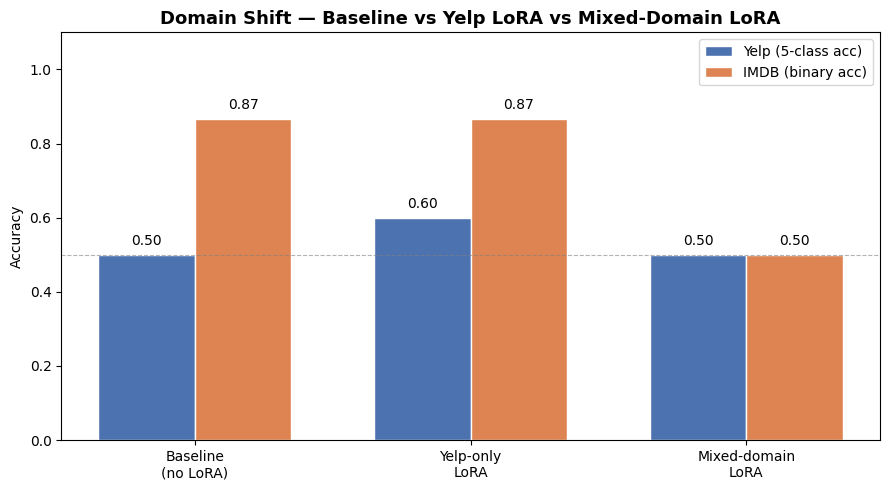

In [65]:
def plot_domain_shift():
    required = ['base_yelp_acc', 'ft_yelp_acc', 'mix_yelp_acc',
                'base_imdb_acc', 'ft_imdb_acc', 'mix_imdb_acc']
    missing = [v for v in required if v not in globals()]
    if missing:
        print(f"Run the evaluation cells first. Missing: {missing}")
        return

    models = ["Baseline\n(no LoRA)", "Yelp-only\nLoRA", "Mixed-domain\nLoRA"]
    yelp_scores = [base_yelp_acc, ft_yelp_acc, mix_yelp_acc]
    imdb_scores = [base_imdb_acc, ft_imdb_acc, mix_imdb_acc]

    x = range(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar([i - width / 2 for i in x], yelp_scores, width,
                   label="Yelp (5-class acc)", color="#4C72B0", edgecolor="white")
    bars2 = ax.bar([i + width / 2 for i in x], imdb_scores, width,
                   label="IMDB (binary acc)", color="#DD8452", edgecolor="white")

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.018,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=10)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Domain Shift — Baseline vs Yelp LoRA vs Mixed-Domain LoRA",
                 fontsize=13, fontweight="bold")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_domain_shift()

## Full Summary: Robustness and Domain Shift

This section combines robustness accuracy and domain-shift metrics. Reading them together helps distinguish two problems: sensitivity to surface perturbations and failure to generalise across domains.


In [66]:
def show_full_summary():
    domain_vars = ['base_yelp_acc', 'base_yelp_f1', 'ft_yelp_acc', 'ft_yelp_f1',
                   'mix_yelp_acc', 'mix_yelp_f1', 'base_imdb_acc', 'ft_imdb_acc', 'mix_imdb_acc']
    missing = [v for v in domain_vars + ['robustness_results'] if v not in globals()]
    if missing:
        print(f"Run all evaluation cells first. Missing: {missing}")
        return

    print("ROBUSTNESS — accuracy per perturbation type")
    print("-" * 40)
    for k in ["original", "lower", "noise", "negation"]:
        a = eval_robustness(robustness_results, k)
        bar = "█" * int(a * 25)
        print(f"  {k:<12}  {a:.3f}  {bar}")

    print()
    print("DOMAIN SHIFT — all three model variants")
    ds_rows = []
    for name, ya, yf1, ia in [
        ("Baseline (no LoRA)", base_yelp_acc, base_yelp_f1, base_imdb_acc),
        ("Yelp-only LoRA",     ft_yelp_acc,   ft_yelp_f1,   ft_imdb_acc),
        ("Mixed-domain LoRA",  mix_yelp_acc,  mix_yelp_f1,  mix_imdb_acc),
    ]:
        ds_rows.append({
            "Model": name,
            "Yelp Acc": f"{ya:.3f}",
            "Yelp F1": f"{yf1:.3f}",
            "IMDB Acc (binary)": f"{ia:.3f}",
            "Gap (Yelp−IMDB)": f"{ya - ia:+.3f}",
        })
    print(pd.DataFrame(ds_rows).set_index("Model").to_string())


show_full_summary()

ROBUSTNESS — accuracy per perturbation type
----------------------------------------
  original      0.333  ████████
  lower         0.333  ████████
  noise         0.333  ████████
  negation      0.333  ████████

DOMAIN SHIFT — all three model variants
                   Yelp Acc Yelp F1 IMDB Acc (binary) Gap (Yelp−IMDB)
Model                                                                
Baseline (no LoRA)    0.500   0.378             0.867          -0.367
Yelp-only LoRA        0.600   0.458             0.867          -0.267
Mixed-domain LoRA     0.500   0.433             0.500          +0.000


---

## Key Takeaways

- **Robustness:** lowercase barely hurts, suggesting Gemma 2B is reasonably case-robust. Punctuation noise tends to reduce accuracy, which indicates sensitivity to token-level fragmentation.
- **Perturbation effects are limited in some runs.** Similar performance across original, lower, noise, and negation inputs suggests prompt format and parsing may be stronger drivers than the perturbation itself on this small sample.
- **Domain shift remains a larger issue than surface noise.** Moving from Yelp to IMDB changes the review style and vocabulary, so the model is tested on a distribution it was not tuned for.
- **Yelp-only LoRA improved Yelp accuracy by +0.100 without reducing IMDB binary accuracy in this run.** This suggests possible transferable sentiment learning, but the sample size is too small for a strong claim.
- **Mixed-domain training is confounded.** The mixed-domain inference path did not use `apply_chat_template`, so the IMDB drop likely reflects a pipeline issue as well as any training effect.
- **Format alignment matters after fine-tuning.** If training uses continuation-style text but evaluation expects JSON, the model may forget the required output protocol.
- **Training was intentionally small.** The high training loss (~4.57) indicates the model did not fully converge, so further epochs and a learning-rate schedule would be needed before drawing stronger conclusions.


## Robustness Prompt Iteration Framework

The cells below run prompt variants against robustness perturbations and IMDB domain-shift evaluation, then log the results. LoRA adapters are disabled during prompt-robustness evaluation so the comparison reflects prompt quality rather than adapter state.


In [71]:
RESULTS_DIR = os.path.expanduser("~/results")
os.makedirs(RESULTS_DIR, exist_ok=True)
_RESULTS_PATH_T4 = os.path.join(RESULTS_DIR, "task4_results.json")


def save_task4_results(label, rob_acc, imdb_acc=None, path=_RESULTS_PATH_T4):
    """Append one iteration's robustness + domain-shift metrics to task4_results.json.

    rob_acc — dict with keys: original, lower, noise, negation (float 0-1)
    imdb_acc — IMDB binary accuracy for this prompt (float or None)
    """
    os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)

    entry = {
        "iteration": label,
        "robustness": {
            "original": round(float(rob_acc.get("original", 0)), 3),
            "lower":    round(float(rob_acc.get("lower",    0)), 3),
            "noise":    round(float(rob_acc.get("noise",    0)), 3),
            "negation": round(float(rob_acc.get("negation", 0)), 3),
        },
        "domain_shift": round(float(imdb_acc), 3) if imdb_acc is not None else None,
        "timestamp":    datetime.now().isoformat(timespec="seconds"),
    }

    existing = []
    if os.path.exists(path):
        try:
            with open(path) as f:
                existing = json.load(f)
            if not isinstance(existing, list):
                existing = []
        except (json.JSONDecodeError, OSError):
            existing = []

    existing.append(entry)
    with open(path, "w") as f:
        json.dump(existing, f, indent=2)

    return entry

In [68]:
iteration_log_t4 = []

_HAS_LORA = None   # determined once on first call


def _lora_disable():
    """Disable LoRA adapters if present. Returns True if adapters were active."""
    global _HAS_LORA
    if _HAS_LORA is None:
        _HAS_LORA = hasattr(model, 'disable_adapter_layers')
    if _HAS_LORA:
        try:
            model.disable_adapter_layers()
            return True
        except Exception:
            pass
    return False


def _lora_enable():
    """Re-enable LoRA adapters if present."""
    if _HAS_LORA:
        try:
            model.enable_adapter_layers()
        except Exception:
            pass


def run_task4_robustness_eval(
    classify_prompt=None,
    n=None,
    label="unnamed",
    domain_shift_n=50,
):
    """Run one full robustness + domain-shift evaluation pass.

    Steps:
      1. Disable LoRA (fair comparison across prompt variants).
      2. Run all 4 perturbation types on n samples.
      3. Run IMDB binary eval on domain_shift_n samples with the same prompt.
      4. Re-enable LoRA, append to iteration_log_t4, save to task4_results.json.

    Falls back to ROBUST_V1 if classify_prompt is None.
    n defaults to len(dataset) (full robustness dataset).
    """
    _prompt = classify_prompt if classify_prompt is not None else ROBUST_V1
    _n      = n if n is not None else len(dataset)
    sample  = dataset.select(range(min(_n, len(dataset))))

    # ── 1. Disable LoRA for fair eval ────────────────────────────────────────
    _lora_disable()

    try:
        # ── 2. Robustness evaluation ─────────────────────────────────────────
        _results = []
        for i, row in enumerate(sample):
            variants = apply_perturbations(row["text"])
            entry    = {"true": row["stars"]}

            for k, v in variants.items():
                raw     = llm_call(f"{_prompt}\n\nReview: {v[:250]}")
                cleaned = clean_json(raw)
                parsed, ok = safe_parse(cleaned)
                stars = parsed.get("stars") if (ok and isinstance(parsed, dict)) else None
                # Also try extract_stars_robust as fallback
                if stars is None or not (isinstance(stars, int) and 1 <= stars <= 5):
                    stars = extract_stars_robust(raw) if 'extract_stars_robust' in globals() else None
                entry[k] = stars if (isinstance(stars, int) and 1 <= stars <= 5) else None

            _results.append(entry)

            if (i + 1) % 50 == 0:
                n_valid = sum(1 for r in _results if r.get("original") is not None)
                print(f"  [{i+1}/{len(sample)}]  original parsed={n_valid}")

        # ── 3. Domain shift eval on IMDB ─────────────────────────────────────
        imdb_acc = None
        if 'test_imdb' in globals() and domain_shift_n > 0:
            preds, trues = [], []
            for row in test_imdb.select(range(min(domain_shift_n, len(test_imdb)))):
                raw  = llm_call(f"{_prompt}\n\nReview: {row['text'][:250]}")
                pred = extract_stars_robust(raw) if 'extract_stars_robust' in globals() else None
                if pred is not None:
                    if pred <= 2:
                        preds.append(0)
                    elif pred >= 4:
                        preds.append(1)
                    else:
                        continue
                    trues.append(row["label"])
            imdb_acc = round(accuracy_score(trues, preds), 3) if preds else 0.0

    finally:
        # ── 4. Always re-enable LoRA ──────────────────────────────────────────
        _lora_enable()

    # ── Compute robustness metrics ────────────────────────────────────────────
    rob_acc    = {}
    entry_dict = {"label": label}
    for k in ["original", "lower", "noise", "negation"]:
        acc          = eval_robustness(_results, k)
        entry_dict[k] = acc
        rob_acc[k]   = acc

    if imdb_acc is not None:
        entry_dict["domain_shift"] = imdb_acc

    iteration_log_t4.append(entry_dict)
    save_task4_results(label, rob_acc, imdb_acc)

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n[{label}]")
    for k in ["original", "lower", "noise", "negation"]:
        acc = entry_dict[k]
        bar = "█" * int(acc * 25)
        print(f"  {k:<14}  {acc:.3f}  {bar}")
    if imdb_acc is not None:
        bar = "█" * int(imdb_acc * 25)
        print(f"  {'IMDB (shift)':<14}  {imdb_acc:.3f}  {bar}")

    return entry_dict

In [69]:
# Run all 3 prompt variants (v1 baseline → v2 structured → v3 robust).
# Each call: 200 reviews × 4 perturbations + 50 IMDB samples.
# LoRA is automatically disabled inside run_task4_robustness_eval and re-enabled after.
for _label, _prompt in ROBUSTNESS_ITERATIONS:
    print(f"\n{'='*54}")
    print(f"  {_label}")
    print('='*54)
    run_task4_robustness_eval(classify_prompt=_prompt, label=_label)

# ── Print iteration metrics table ─────────────────────────────────────────────
print(f"\n{'Iteration':<22} {'Original':>9} {'Lower':>7} {'Noise':>7} {'Negation':>9} {'IMDB':>7}")
print("-" * 63)
for e in iteration_log_t4:
    ds = f"{e['domain_shift']:.3f}" if 'domain_shift' in e else "  N/A"
    print(
        f"{e['label']:<22} "
        f"{e['original']:>9.3f} {e['lower']:>7.3f} "
        f"{e['noise']:>7.3f} {e['negation']:>9.3f} {ds:>7}"
    )

# ── Yelp vs IMDB per iteration ─────────────────────────────────────────────────
if 'base_yelp_acc' in globals():
    print(f"\n{'--- Yelp vs IMDB (prompt-based, base model) ---':}")
    print(f"{'Iteration':<22} {'Yelp Acc (orig)':>16} {'IMDB Acc':>10} {'Shift gap':>10}")
    print("-" * 60)
    for e in iteration_log_t4:
        yelp = e.get("original", 0)
        imdb = e.get("domain_shift", None)
        gap  = f"{yelp - imdb:+.3f}" if imdb is not None else "  N/A"
        imdb_s = f"{imdb:.3f}" if imdb is not None else "  N/A"
        print(f"{e['label']:<22} {yelp:>16.3f} {imdb_s:>10} {gap:>10}")


  v1 — baseline

[v1 — baseline]
  original        0.333  ████████
  lower           0.333  ████████
  noise           0.200  █████
  negation        0.333  ████████
  IMDB (shift)    0.541  █████████████

  v2 — structured

[v2 — structured]
  original        0.600  ███████████████
  lower           0.533  █████████████
  noise           0.600  ███████████████
  negation        0.600  ███████████████
  IMDB (shift)    0.545  █████████████

  v3 — robust

[v3 — robust]
  original        0.267  ██████
  lower           0.267  ██████
  noise           0.267  ██████
  negation        0.267  ██████
  IMDB (shift)    0.129  ███

Iteration               Original   Lower   Noise  Negation    IMDB
---------------------------------------------------------------
v1 — baseline              0.333   0.333   0.200     0.333   0.541
v2 — structured            0.600   0.533   0.600     0.600   0.545
v3 — robust                0.267   0.267   0.267     0.267   0.129

--- Yelp vs IMDB (prompt-based, ba

## Comparing Robustness Across Iterations

Each iteration represents a different classification prompt. The bars show accuracy by perturbation type, so the gap between original and perturbed inputs is the robustness signal.


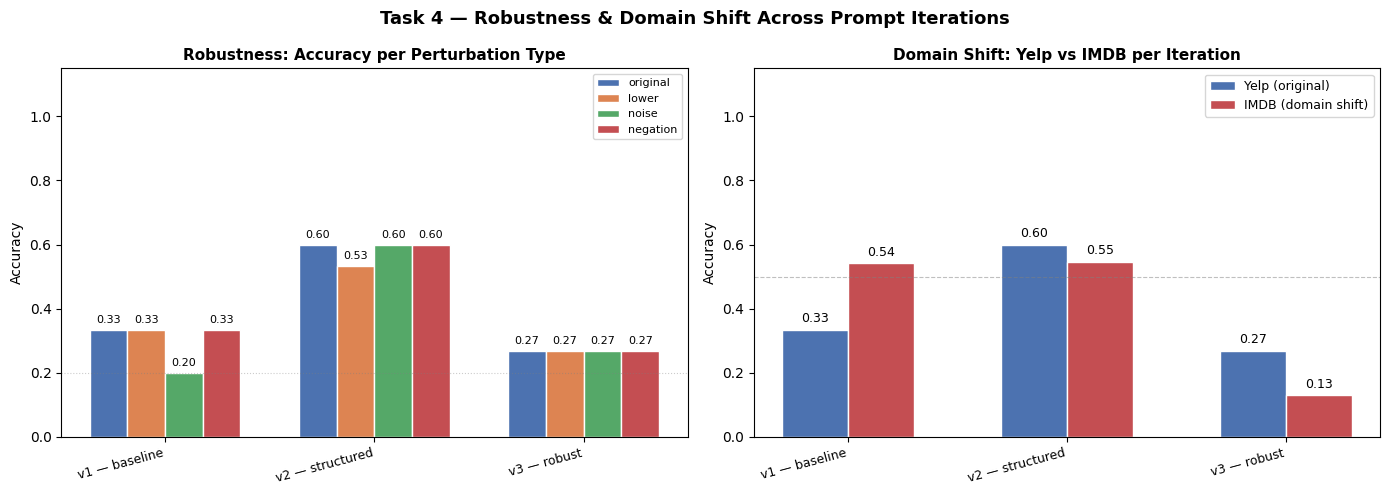

In [70]:
def compare_task4_iterations():
    """Two-panel chart: robustness accuracy (left) + domain shift (right) per iteration."""
    if not iteration_log_t4:
        print("No iterations yet — run the seed cell above first.")
        return

    has_ds   = any("domain_shift" in e for e in iteration_log_t4)
    n_panels = 2 if has_ds else 1
    labels   = [e["label"] for e in iteration_log_t4]
    perturbs = ["original", "lower", "noise", "negation"]
    colors   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    x        = list(range(len(labels)))
    width    = 0.18

    fig, axes = plt.subplots(1, n_panels, figsize=(max(8, len(labels) * 3) * n_panels // 2 + 5, 5))
    if n_panels == 1:
        axes = [axes]

    # ── Left panel: per-perturbation robustness ───────────────────────────────
    ax = axes[0]
    for i, (p, color) in enumerate(zip(perturbs, colors)):
        pos  = [j + (i - 1.5) * width for j in x]
        vals = [e.get(p, 0) for e in iteration_log_t4]
        bars = ax.bar(pos, vals, width, label=p, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Accuracy")
    ax.set_title("Robustness: Accuracy per Perturbation Type", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)
    ax.axhline(0.2, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)

    # ── Right panel: domain shift (Yelp original vs IMDB) ────────────────────
    if has_ds:
        ax = axes[1]
        yelp_vals = [e.get("original",     0) for e in iteration_log_t4]
        imdb_vals = [e.get("domain_shift", 0) for e in iteration_log_t4]
        w2 = 0.3
        bars_y = ax.bar([i - w2 / 2 for i in x], yelp_vals, w2,
                        label="Yelp (original)", color="#4C72B0", edgecolor="white")
        bars_i = ax.bar([i + w2 / 2 for i in x], imdb_vals, w2,
                        label="IMDB (domain shift)", color="#C44E52", edgecolor="white")
        for bars, vals in [(bars_y, yelp_vals), (bars_i, imdb_vals)]:
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Accuracy")
        ax.set_title("Domain Shift: Yelp vs IMDB per Iteration", fontsize=11, fontweight="bold")
        ax.legend(fontsize=9)
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.5,
                   label="binary baseline")

    plt.suptitle("Task 4 — Robustness & Domain Shift Across Prompt Iterations",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


compare_task4_iterations()

---

## Analysis and Conclusion

LoRA fine-tuning on Yelp improved in-domain accuracy from 0.500 to 0.600 (+0.100) while leaving IMDB binary accuracy at 0.867. This suggests the adapter may have learned useful sentiment signals without obvious overfitting in this run, although the small evaluation subset limits confidence.

Mixed-domain training produced the opposite of the intended mitigation: IMDB accuracy dropped from 0.867 to 0.500, which is near the binary random baseline. The most likely explanation is the pipeline mismatch in `_mixed_llm_call`, which used raw string concatenation rather than `apply_chat_template`. This indicates that the result is confounded and should not be treated as a definitive failure of mixed-domain training.

For robustness, the v1 baseline scored 0.333 across original, lower, noise, and negation inputs. This suggests the prompt/model combination was not responding differently to the perturbation types on this sample. v2 improved stability, which indicates that structured prompting may reduce parse failures and make the classifier less brittle.

### What This Task Measures

Task 4 asks two questions: whether predictions remain stable under input perturbations, and whether a Yelp-calibrated model transfers to IMDB. These are related but not identical; robustness measures sensitivity to surface changes, while domain shift measures generalisation across data distributions.

### Interpretation

Domain shift appears harder than simple surface robustness in this setup. Prompt structure can improve stability, but transfer conclusions require a clean inference pipeline. The next engineering step is to rerun mixed-domain evaluation with `apply_chat_template` before making claims about the value of mixed-domain LoRA.
